In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

XGBoost version: 3.2.0


## Read and Split the data 

In [4]:
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_val,y_val = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


[-31.608 -29.544   6.773   9.554] 0
[46.451 15.318 24.891 15.357] 0
[ 24.771  46.131 -49.161 -39.356] 0
[-20.13   15.641  30.981  37.218] 0
[46.465 22.369 14.248 21.745] 0


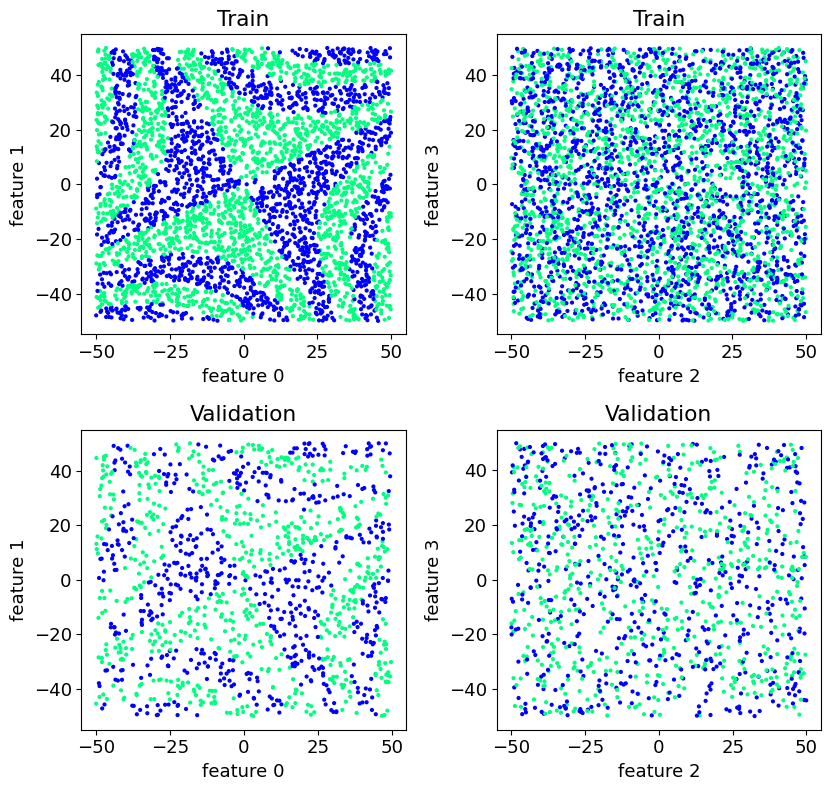

In [6]:
def scat(ax,x,y,i=0,j=1,s=4,title=""):
    # scatter plot of the data in the plane of features i and j
    ax.scatter(x[:,i],x[:,j],s=s,c=y) 
    ax.set_xlabel(f"feature {i}")
    ax.set_ylabel(f"feature {j}")
    ax.set_title(title)

# print the first 5 data points
for n in range(5):
    print(x[n],y[n])

#print feature plots for the training and test sets
fig,AX = plt.subplots(2,2,figsize=(8.5,8.1))
scat(AX[0,0],x_train,y_train,title="Train")
scat(AX[0,1],x_train,y_train,i=2,j=3,title="Train")
scat(AX[1,0],x_val,y_val,title="Validation")
scat(AX[1,1],x_val,y_val,i=2,j=3,title="Validation")
fig.tight_layout()
plt.show()

In [7]:
def classify(clf=GradientBoostingClassifier(),show=False):
    # GradientBoostingClassifier():
    #   n_estimators = 100 (default)
    #   loss function = deviance(default) used in Logistic Regression
    # XGBClassifier()
    #   n_estimators = 100 (default)
    #   max_depth = 3 (default?)
    
    clf.fit(x_train,y_train) # train the model on the training set
    y_hat = clf.predict(x_val) # predict the labels of the test set
    
    print("errors: {:.2f}%   Accuracy={:.3f}".format(100*(1-clf.score(x_val, y_val)),clf.score(x_val, y_val)))
    S=50 # size of the square grid
    dx = 1
    x_seq=np.arange(-S,S+dx,dx) # sequence of points for the grid
    nx = len(x_seq)
    x_plot=np.zeros((nx*nx,L)) # grid of points
    print('shape of x_plot=',x_plot.shape)
    q=0
    for i in range(nx):
        for j in range(nx):
            x_plot[q,:2] = [x_seq[i],x_seq[j]] # only the first two features are used for the artificial grid
            q+=1
    y_plot= clf.predict(x_plot) # predict the labels of the grid points

    fig,AX = plt.subplots(1,2,figsize=(8.2,4))
    scat(AX[0],x_plot[:],y_plot,s=dx,title="predicted")
    scat(AX[1],x_train[:],y_train,title="training set")
    fig.tight_layout()
    plt.show()
    
    if show:      
        dump_list = clf.get_booster().get_dump() # get the list of trees in the model
        num_trees = len(dump_list)
        print("num_trees=",num_trees)
        
        fig, AX = plt.subplots(2,1,figsize=(12, 5))
        for i in range(min(2,num_trees)):
            ax=AX[i]
            plot_tree(clf, num_trees=i, ax=ax)
        fig.savefig("DATA/tree-classif.png", dpi=400, pad_inches=0.02)   
        plt.show()

In [9]:
gamma=[0, 1]
reg_lambda= [0.001, 1, 10] 
n_estimators=[ 5, 10, 30]
max_depth= [2, 3, 5]

results=[]

for n in n_estimators:
    for depth in max_depth:
        for lam in reg_lambda:
            for gam in gamma:

                model= XGBClassifier( n_estimators= n, max_depth= depth, reg_lambda= lam, 
                                     gamma= gam, objective= 'binary:logistic', seed= 1)

                model.fit( x_train, y_train)
                acc= model.score( x_val, y_val)
                results.append((acc, n, depth, lam, gam))

                print( f'acc={acc:.3f}, n_estn_estimators={n}, depth={depth}, lambda= {lam}, gamma={gam}')

                

acc=0.611, n_estn_estimators=5, depth=2, lambda= 0.001, gamma=0
acc=0.611, n_estn_estimators=5, depth=2, lambda= 0.001, gamma=1
acc=0.611, n_estn_estimators=5, depth=2, lambda= 1, gamma=0
acc=0.611, n_estn_estimators=5, depth=2, lambda= 1, gamma=1
acc=0.578, n_estn_estimators=5, depth=2, lambda= 10, gamma=0
acc=0.578, n_estn_estimators=5, depth=2, lambda= 10, gamma=1
acc=0.686, n_estn_estimators=5, depth=3, lambda= 0.001, gamma=0
acc=0.686, n_estn_estimators=5, depth=3, lambda= 0.001, gamma=1
acc=0.686, n_estn_estimators=5, depth=3, lambda= 1, gamma=0
acc=0.686, n_estn_estimators=5, depth=3, lambda= 1, gamma=1
acc=0.693, n_estn_estimators=5, depth=3, lambda= 10, gamma=0
acc=0.693, n_estn_estimators=5, depth=3, lambda= 10, gamma=1
acc=0.814, n_estn_estimators=5, depth=5, lambda= 0.001, gamma=0
acc=0.814, n_estn_estimators=5, depth=5, lambda= 0.001, gamma=1
acc=0.790, n_estn_estimators=5, depth=5, lambda= 1, gamma=0
acc=0.790, n_estn_estimators=5, depth=5, lambda= 1, gamma=1
acc=0.781, n

In [39]:
results.sort( reverse=True)

best_models_list=[]
print( 'best models:')
for r in results[:5]:
    best_models_list.append(r)
    print( f'acc={r[0]:.3f}, estimators={r[1]}, depth={r[2]}, lambda={r[3]}, gamma= {r[4]}')


best models:
acc=0.893, estimators=30, depth=5, lambda=0.001, gamma= 0
acc=0.886, estimators=30, depth=5, lambda=1, gamma= 1
acc=0.885, estimators=30, depth=5, lambda=10, gamma= 0
acc=0.882, estimators=30, depth=5, lambda=1, gamma= 0
acc=0.880, estimators=30, depth=5, lambda=10, gamma= 1


              Models with estimators=30, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 10.72%   Accuracy=0.893
shape of x_plot= (10201, 4)


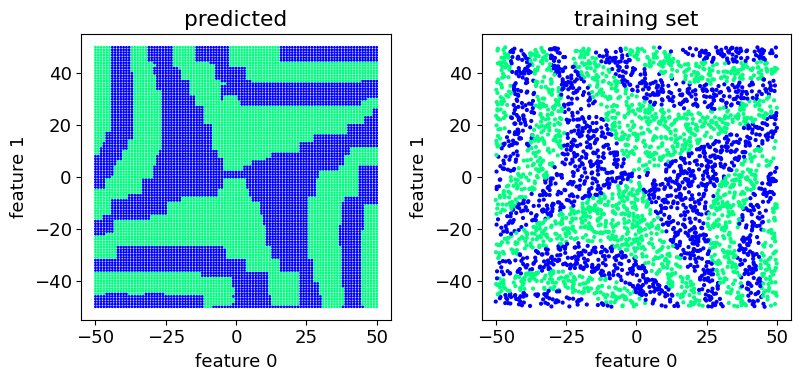

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


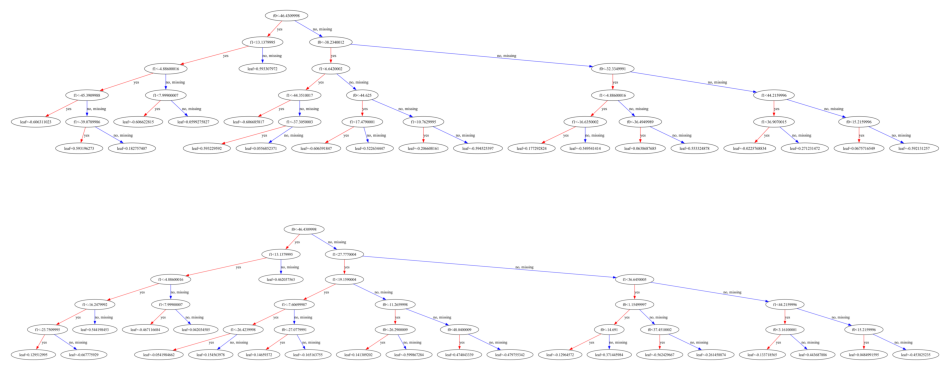

              Models with estimators=30, max_depth=5, reg_lambda=1, gamma=1 

errors: 11.36%   Accuracy=0.886
shape of x_plot= (10201, 4)


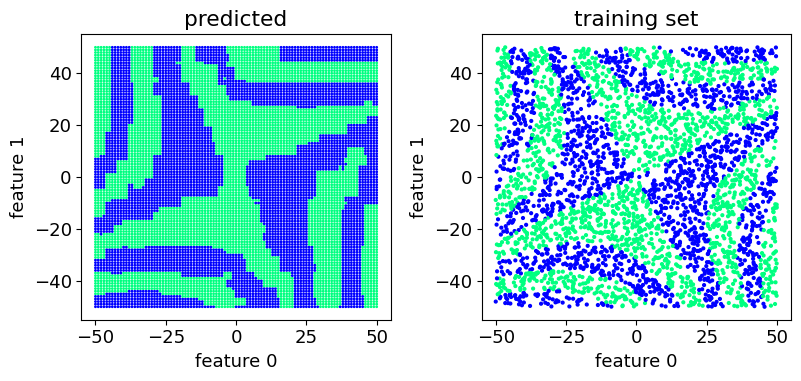

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


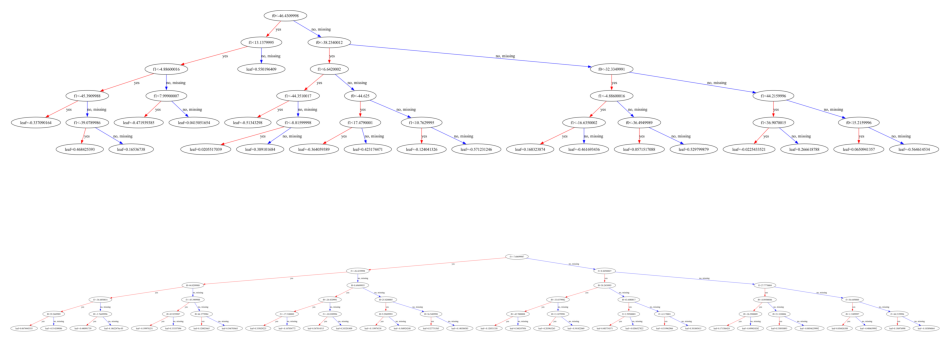

              Models with estimators=30, max_depth=5, reg_lambda=10, gamma=0 

errors: 11.52%   Accuracy=0.885
shape of x_plot= (10201, 4)


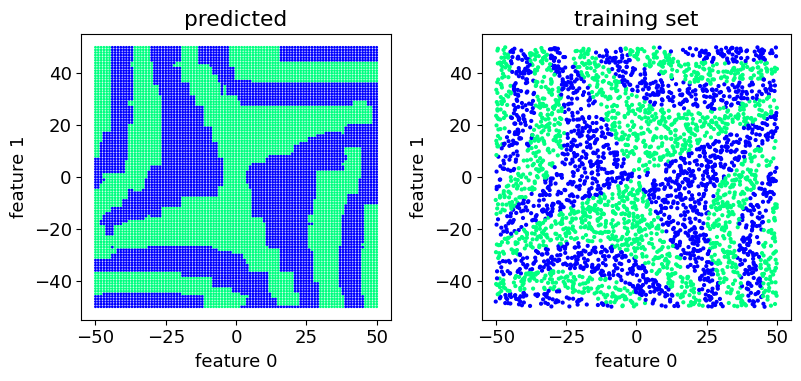

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


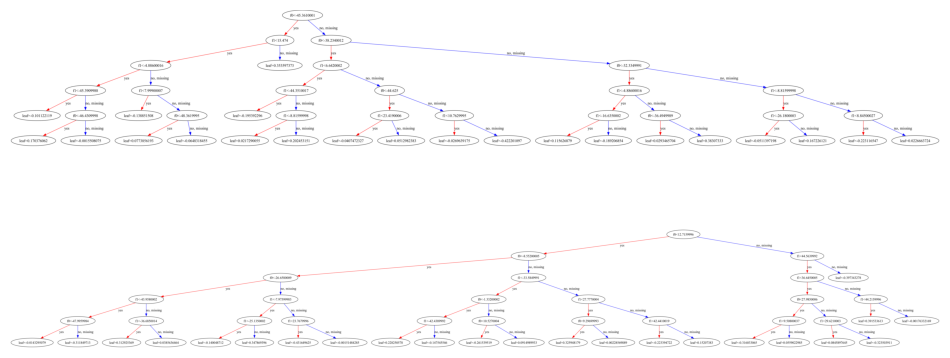

              Models with estimators=30, max_depth=5, reg_lambda=1, gamma=0 

errors: 11.76%   Accuracy=0.882
shape of x_plot= (10201, 4)


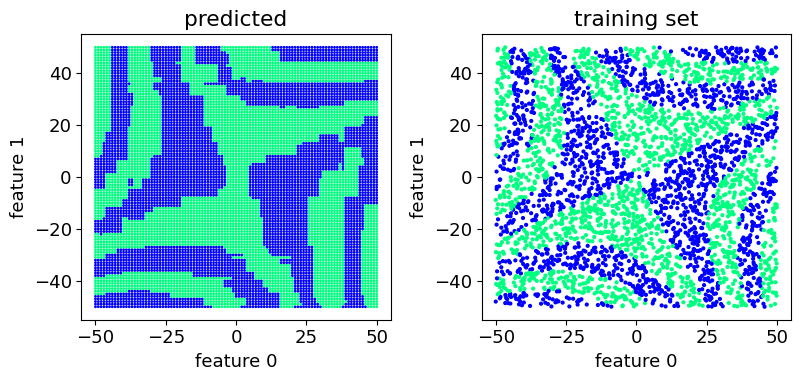

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


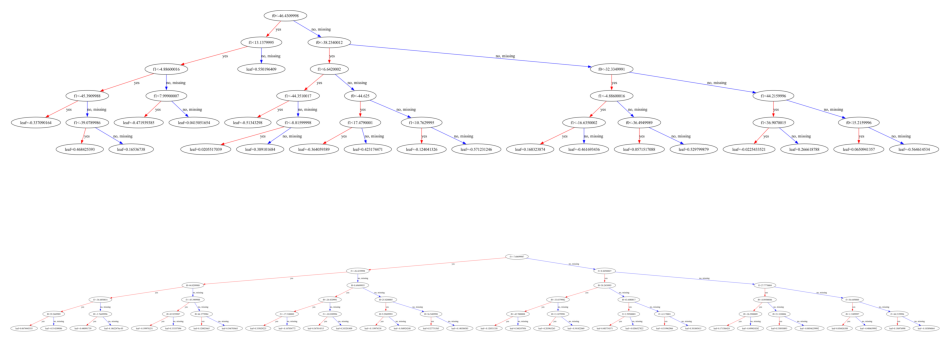

              Models with estimators=30, max_depth=5, reg_lambda=10, gamma=1 

errors: 12.00%   Accuracy=0.880
shape of x_plot= (10201, 4)


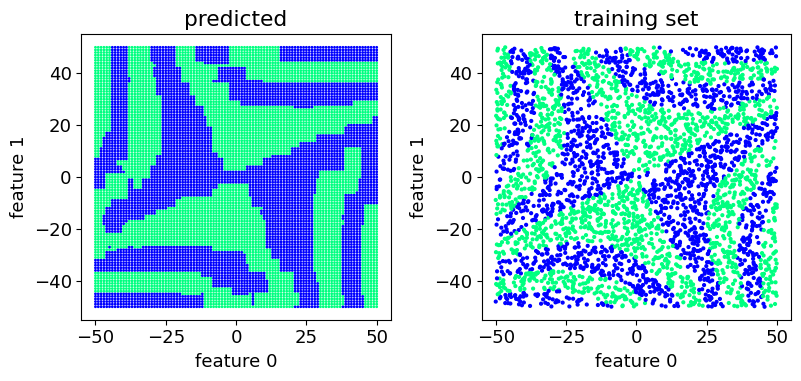

num_trees= 30


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


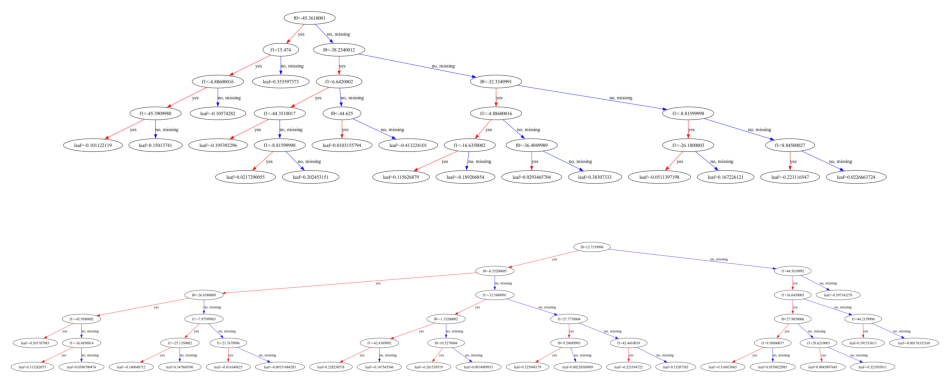

In [20]:
#uso classify solo sui migliori:

for best in best_models_list:

    acc, n_estimators, depth, reg_lambda, gamma = best
    
    best_model= XGBClassifier( n_estimators= n_estimators, max_depth= depth, 
                          reg_lambda= reg_lambda, gamma=gamma, objective='binary:logistic',
                          seed=1)
    print( f'              Models with estimators={n_estimators}, max_depth={depth}, reg_lambda={reg_lambda}, gamma={gamma} \n')
    classify(best_model, show=True)

              Models with estimators=10, max_depth=5, reg_lambda=0.001, gamma=0 

errors: 13.36%   Accuracy=0.866
shape of x_plot= (10201, 4)


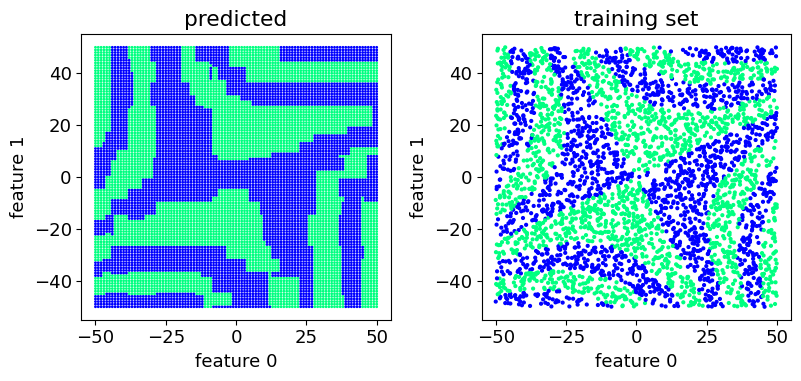

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


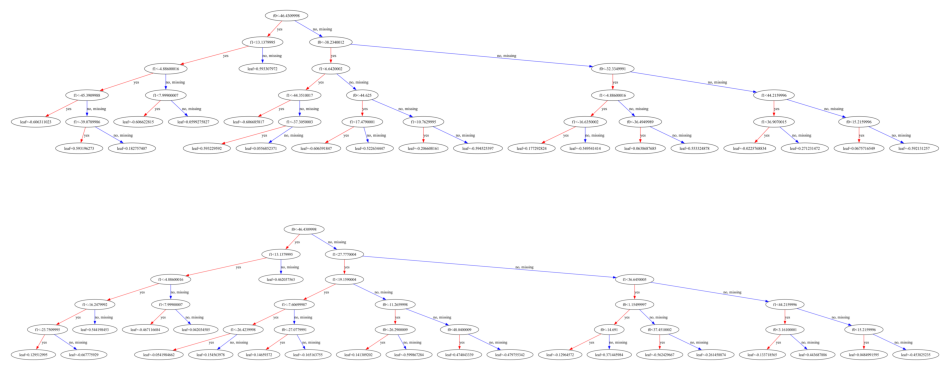

              Models with estimators=10, max_depth=5, reg_lambda=0.001, gamma=1 

errors: 14.16%   Accuracy=0.858
shape of x_plot= (10201, 4)


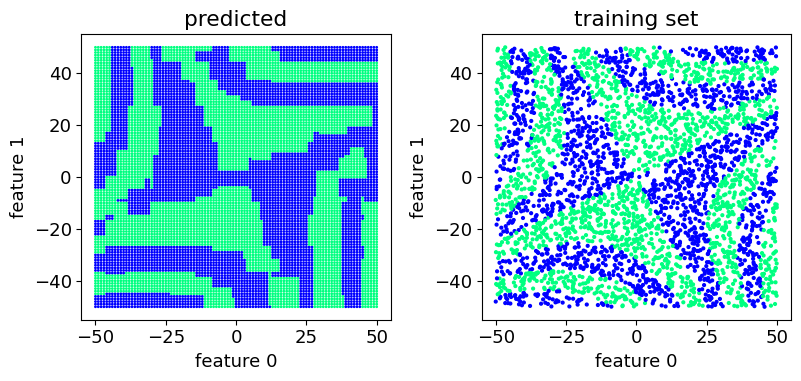

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


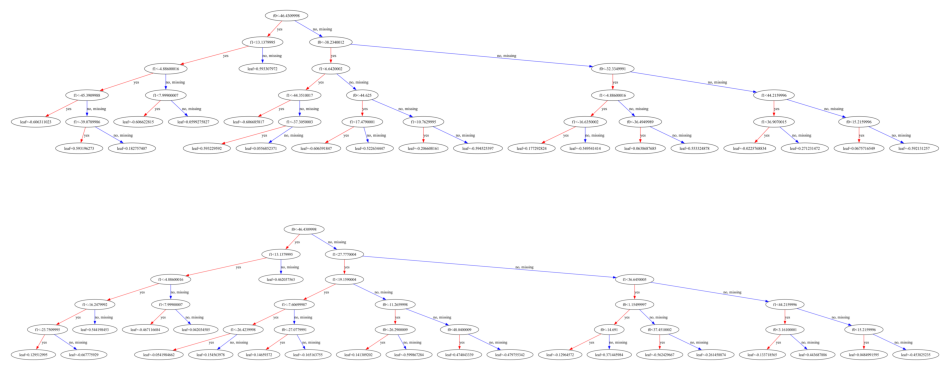

              Models with estimators=10, max_depth=5, reg_lambda=1, gamma=1 

errors: 15.52%   Accuracy=0.845
shape of x_plot= (10201, 4)


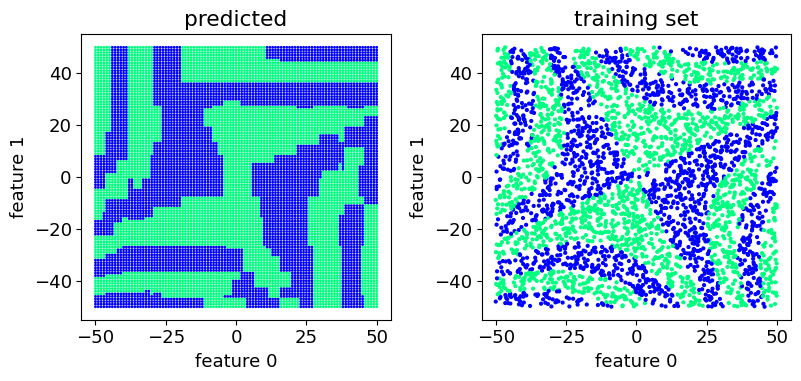

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


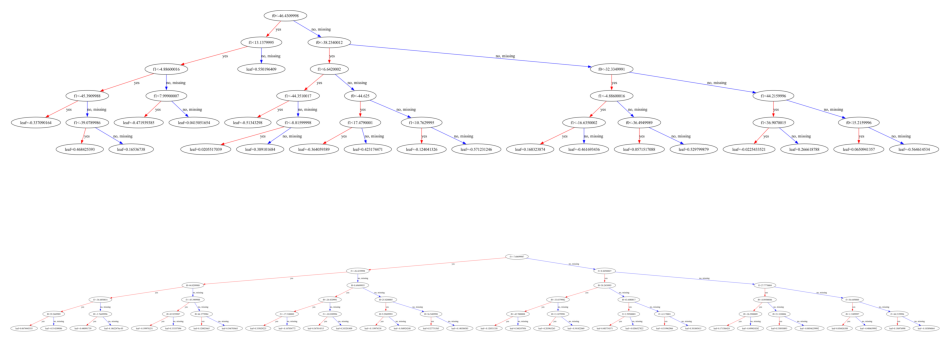

              Models with estimators=10, max_depth=5, reg_lambda=1, gamma=0 

errors: 15.52%   Accuracy=0.845
shape of x_plot= (10201, 4)


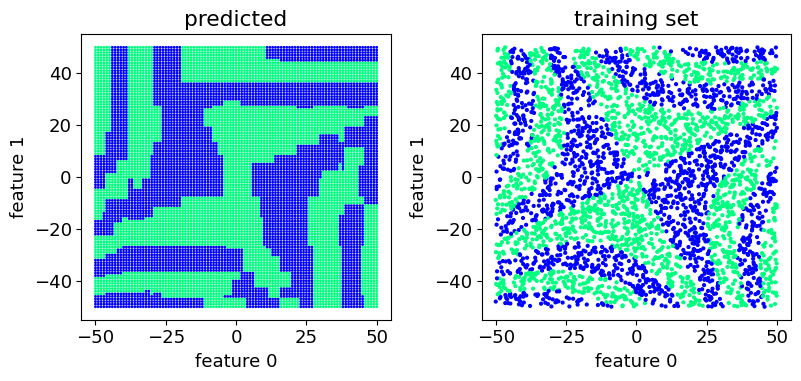

num_trees= 10


/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(
/opt/anaconda3/envs/LCPB_2526/lib/python3.11/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


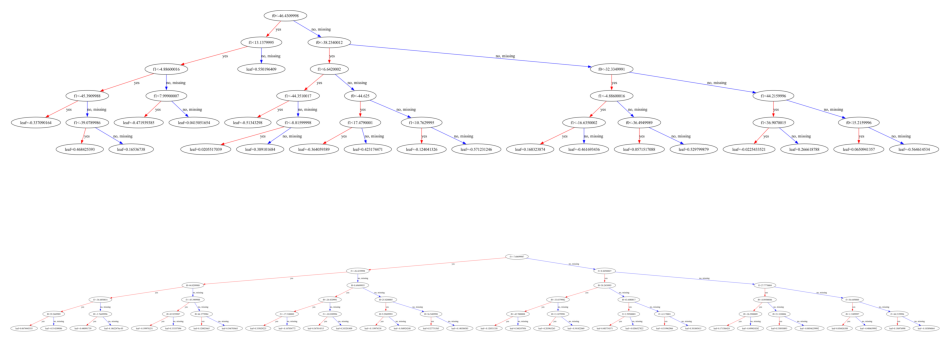

In [43]:

for model in results:
    acc, n_estimators, depth, reg_lambda, gamma = model

    if acc>= 0.840:
        if n_estimators< 30 or depth <5:
            model= XGBClassifier( n_estimators= n_estimators, max_depth= depth, 
                          reg_lambda= reg_lambda, gamma=gamma, objective='binary:logistic',
                          seed=1)
            
            print( f'              Models with estimators={n_estimators}, max_depth={depth}, reg_lambda={reg_lambda}, gamma={gamma} \n')
            classify(model, show=True)
        


To simplify the model, we can reduce the maximum depth and keep the number of estimators as low as possible, while maintaining a validation accuracy above 0.80. In our experiments, all the best models required 30 estimators and depth = 5 to achieve the highest accuracy (0.94–0.95). So, to find models that have an high validation accuracy we search for a number of estimators less then 30, and a max depth less then 5. 

Regularization (L2 lambda or gamma) does not significantly improve validation accuracy in this dataset. Since the dataset is clean and only the first two features are relevant, the model naturally focuses on them. Regularization could be useful in noisier datasets to prevent overfitting, but it is not essential here.